In [ ]:
# ── CELDA 1: Instalar dependencias ────────────────────────────
!pip install cdsapi xarray netCDF4 cartopy -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 40.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 23.6 MB/s eta 0:00:00


In [ ]:
import os
import cdsapi

from google.colab import drive
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import shutil

In [ ]:
# Solo necesitas el token — ya no hay UID separado
CDS_TOKEN = 'c9066123-1988-47d5-872b-8679903a850a'

cds_config = f"""url: https://cds.climate.copernicus.eu/api
key: {CDS_TOKEN}
verify: 0
"""

with open(os.path.expanduser('~/.cdsapirc'), 'w') as f:
    f.write(cds_config)

print('Credenciales guardadas correctamente')

Credenciales guardadas correctamente


In [ ]:
# ── CELDA 3: Verificar acceso ──────────────────────────────────
c = cdsapi.Client()
print('Conexión exitosa con CDS API')

/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'cds.climate.copernicus.eu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Conexión exitosa con CDS API


In [ ]:
# ── CELDA 4: Descarga ERA5 — todas las variables, año 2023 ─────

# Carpeta de salida en Colab (luego la descargas a Drive)
os.makedirs('/content/era5', exist_ok=True)

# Variables ERA5 completo y su nombre en la API
VARIABLES = [
    '2m_temperature',           # t2m
    '10m_u_component_of_wind',  # viento componente U
    '10m_v_component_of_wind',  # viento componente V
    'boundary_layer_height',    # BLH
    '2m_dewpoint_temperature',  # para calcular RH
]

# Área: Norte, Oeste, Sur, Este — bbox Cali
AREA = [3.75, -76.75, 3.20, -76.30]

MESES = [str(m).zfill(2) for m in range(1, 13)]
DIAS  = [str(d).zfill(2) for d in range(1, 32)]
HORAS = ['00:00', '06:00', '12:00', '18:00']  # 4 snapshots diarios

print('Iniciando descarga ERA5 para Cali 2020...')
print('Esto puede tardar 10-20 minutos según la cola de CDS\n')

c.retrieve(
    'reanalysis-era5-single-levels',
    {
        'product_type': 'reanalysis',
        'variable': VARIABLES,
        'year': '2020',
        'month': MESES,
        'day': DIAS,
        'time': HORAS,
        'area': AREA,
        'format': 'netcdf',
    },
    '/content/era5/ERA5_Cali_2023.nc'
)

print('\nDescarga completada')

Iniciando descarga ERA5 para Cali 2020...
Esto puede tardar 10-20 minutos según la cola de CDS



/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'cds.climate.copernicus.eu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'cds.climate.copernicus.eu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
2026-05-08 23:13:11,333 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an effic

6d951006ad03c71826001d6aeb310e3e.nc:   0%|          | 0.00/179k [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'object-store.os-api.cci2.ecmwf.int'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(



Descarga completada


In [ ]:
# ── CELDA 5: Calcular RH a partir de t2m y dewpoint ───────────
# ERA5 no entrega RH directamente — se calcula con la fórmula de Magnus

ds = xr.open_dataset('/content/era5/ERA5_Cali_2023.nc')
print('Variables disponibles:', list(ds.data_vars))
print('Dimensiones:', dict(ds.dims))
print('Período:', ds.valid_time.values[0], '→', ds.valid_time.values[-1])

# Fórmula de Magnus para RH
# t2m y d2m vienen en Kelvin — convertir a Celsius
t2m = ds['t2m'] - 273.15   # temperatura 2m en °C
d2m = ds['d2m'] - 273.15   # dewpoint 2m en °C

# RH (%) usando aproximación de Magnus
RH = 100 * np.exp((17.625 * d2m) / (243.04 + d2m)) / \
           np.exp((17.625 * t2m) / (243.04 + t2m))

# Agregar RH al dataset
ds['RH'] = RH
ds['RH'].attrs = {
    'long_name': 'Relative Humidity',
    'units': '%',
    'description': 'Calculada desde t2m y d2m via formula de Magnus'
}

print('\nRH calculada correctamente')
print(f'Rango RH: {float(RH.min()):.1f}% - {float(RH.max()):.1f}%')

Variables disponibles: ['t2m', 'u10', 'v10', 'blh', 'd2m']
Dimensiones: {'valid_time': 1464, 'latitude': 1, 'longitude': 1}
Período: 2020-01-01T00:00:00.000000000 → 2020-12-31T18:00:00.000000000

RH calculada correctamente
Rango RH: 53.1% - 100.0%


/tmp/ipykernel_2379/4229557926.py:6: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print('Dimensiones:', dict(ds.dims))


In [ ]:
# ── CELDA 6: Calcular magnitud del viento ─────────────────────
# ERA5 entrega componentes U y V — combinamos en velocidad total

u10 = ds['u10']  # componente U (este-oeste)
v10 = ds['v10']  # componente V (norte-sur)

ds['wind_speed'] = np.sqrt(u10**2 + v10**2)
ds['wind_speed'].attrs = {
    'long_name': 'Wind Speed at 10m',
    'units': 'm/s',
    'description': 'Magnitud calculada desde u10 y v10'
}

print('Velocidad de viento calculada')
print(f'Rango: {float(ds.wind_speed.min()):.2f} - {float(ds.wind_speed.max()):.2f} m/s')

Velocidad de viento calculada
Rango: 0.05 - 2.71 m/s


In [ ]:
# ── CELDA 7: Guardar dataset final con todas las variables ─────

# Seleccionar solo las variables finales que necesitamos
variables_finales = ['t2m', 'blh', 'RH', 'wind_speed', 'u10', 'v10']
ds_final = ds[variables_finales]

output_path = '/content/era5/ERA5_Cali_2023_procesado.nc'
ds_final.to_netcdf(output_path)

tamanio_mb = os.path.getsize(output_path) / 1e6
print(f'Dataset guardado: {output_path}')
print(f'Tamaño: {tamanio_mb:.1f} MB')
print(f'Variables: {list(ds_final.data_vars)}')

Dataset guardado: /content/era5/ERA5_Cali_2023_procesado.nc
Tamaño: 0.2 MB
Variables: ['t2m', 'blh', 'RH', 'wind_speed', 'u10', 'v10']


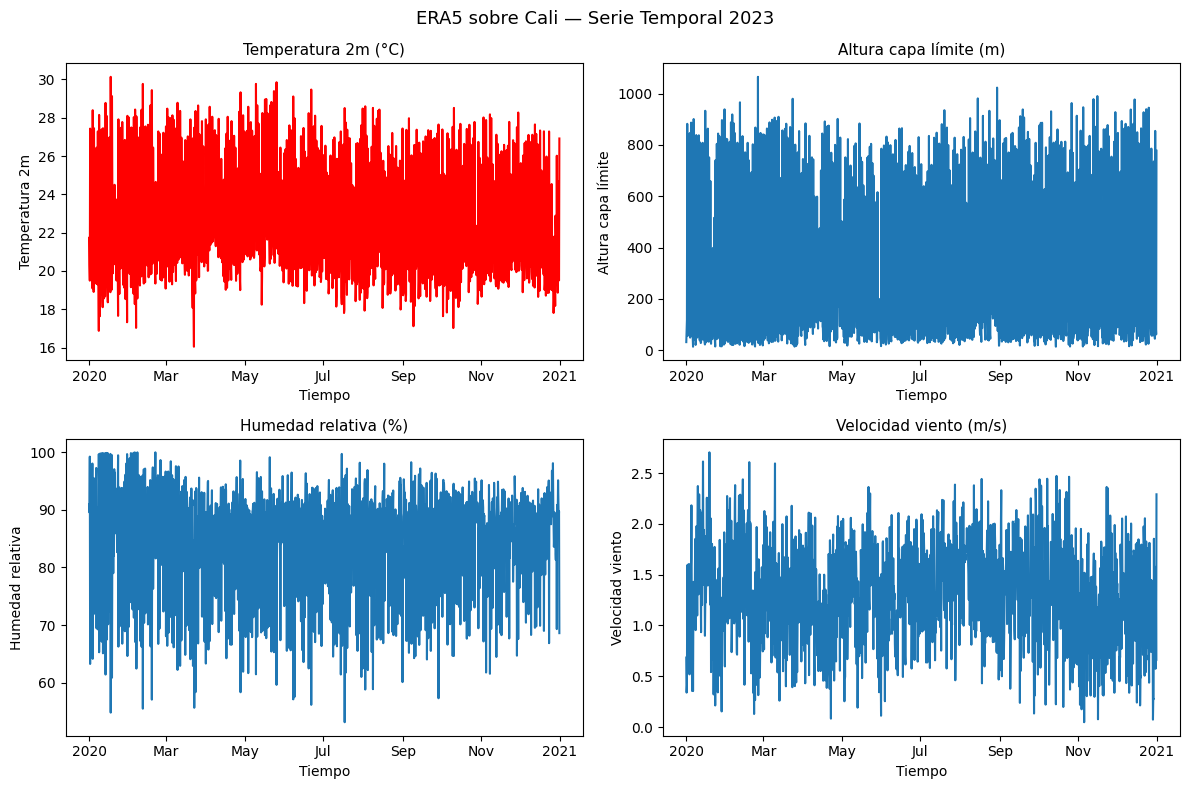

Visualización guardada


In [ ]:
# ── CELDA 8: Visualización rápida de verificación ─────────────

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Para un punto geográfico, la visualización más útil es la serie temporal.
# Squeezed elimina las dimensiones de tamaño 1 (latitud, longitud)

vars_plot = [
    ('t2m',        'Temperatura 2m (°C)',        'RdYlBu_r'),
    ('blh',        'Altura capa límite (m)',     'YlOrRd'),
    ('RH',         'Humedad relativa (%)',        'Blues'),
    ('wind_speed', 'Velocidad viento (m/s)',      'Greens'),
]

for ax, (var, titulo, _) in zip(axes.flatten(), vars_plot):
    # Convert t2m to Celsius for plotting if it was K
    if var == 't2m':
        (ds_final[var] - 273.15).squeeze().plot(ax=ax, linewidth=1.5, color='red')
    else:
        ds_final[var].squeeze().plot(ax=ax, linewidth=1.5)
    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel('Tiempo')
    ax.set_ylabel(titulo.split(' (')[0]) # Use the variable's name as y-label

plt.suptitle('ERA5 sobre Cali — Serie Temporal 2023', fontsize=13)
plt.tight_layout()
plt.savefig('/content/era5/verificacion_era5.png', dpi=150)
plt.show()
print('Visualización guardada')

In [ ]:
# ── CELDA 9: Guardar en Google Drive ──────────────────────────
drive.mount('/content/drive')


destino = '/content/drive/MyDrive/geovision_era5/'
os.makedirs(destino, exist_ok=True)

shutil.copy(output_path, destino + 'ERA5_Cali_2023_procesado.nc')
shutil.copy('/content/era5/verificacion_era5.png', destino + 'verificacion_era5.png')

print(f'Archivos copiados a Drive: {destino}')

Mounted at /content/drive
Archivos copiados a Drive: /content/drive/MyDrive/geovision_era5/
